In [18]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

from derivative import dxdt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

dt = 0.5
t_span = (0, 20)

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

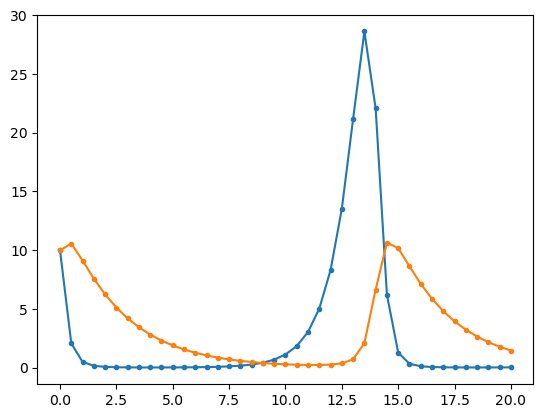

In [20]:
x_train = generate_training_data(lotka_volterra_rhs, x0, t_eval)

plt.plot(t_eval, x_train.T, '.-')
plt.show()

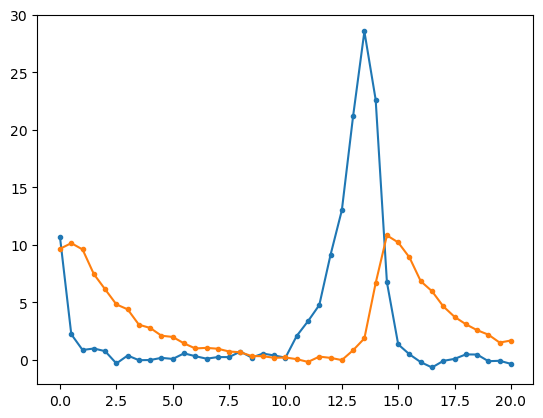

In [21]:
x_train_noisy = add_noise_to_data(x_train, 0.05)

# plt.plot(t_eval, x_train.T)
plt.plot(t_eval, x_train_noisy.T, '.-')
plt.show()

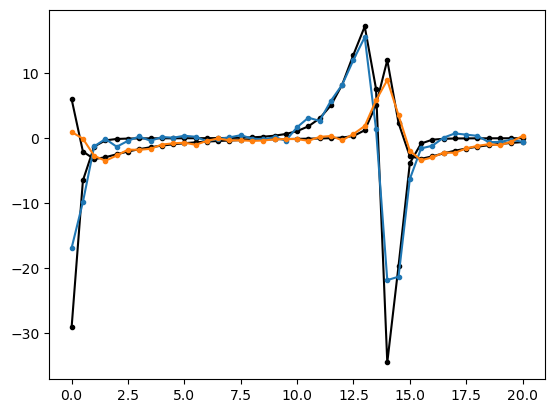

0.9377163255226003

In [22]:
# generate the true derivative
x_dot_true = lotka_volterra_rhs(t_eval, x_train)

x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)

x_dot_approx_kalman = dxdt(x_train_noisy, t_eval, kind='kalman', alpha=0.01)
x_dot_approx_poly = dxdt_poly_fit(x_train_noisy, t_eval, poly_deg=3, window_diameter=10)

plt.plot(t_eval, x_dot_true.T, 'k.-')
plt.plot(t_eval, x_dot_approx.T, '.-')
# plt.plot(t_eval, x_dot_approx_kalman.T, 'b.-')
# plt.plot(t_eval, x_dot_approx_poly.T, 'g.-')
plt.show()

np.mean(np.abs(x_dot_true - x_dot_approx))

dt: 0.01, MSE: -0.0041006330046021965
dt: 0.016681005372000592, MSE: -0.007857473624068046
dt: 0.027825594022071243, MSE: 0.009048191672960169
dt: 0.046415888336127774, MSE: 0.013112956858762466
dt: 0.0774263682681127, MSE: -0.01741846326763168
dt: 0.1291549665014884, MSE: 0.018197788458874358
dt: 0.21544346900318834, MSE: -0.0022874276053931448
dt: 0.3593813663804626, MSE: -0.0401090059425842
dt: 0.5994842503189409, MSE: -0.09677573143854516
dt: 1.0, MSE: -0.398262482146484


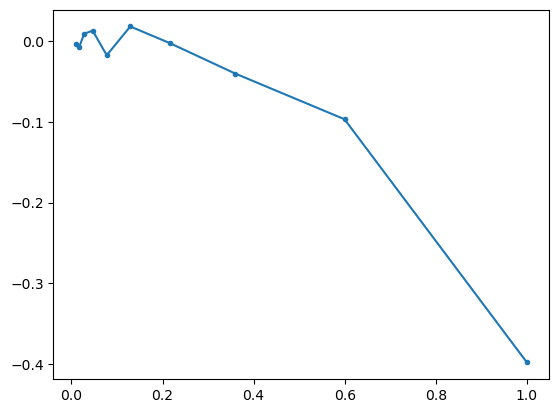

In [30]:
dt = 0.5
t_span = (0, 20)

dts = np.logspace(-2, 0, 10)
mses = []

for dt in dts:
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    x_train = generate_training_data(lotka_volterra_rhs, x0, t_eval)

    x_train_noisy = add_noise_to_data(x_train, 0.05, seed=42)

    x_dot_true = lotka_volterra_rhs(t_eval, x_train)
    x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)

    # mse = np.mean((x_dot_true - x_dot_approx)**2)
    mse = np.mean(x_dot_true - x_dot_approx)
    mses.append(mse)

    print(f"dt: {dt}, MSE: {mse}")

plt.plot(dts, mses, '.-')